In [252]:
from diffusers import AutoencoderKL, DDPMScheduler, DiffusionPipeline, UNet2DConditionModel
import argparse
import copy
import gc
import hashlib
import itertools
import logging
import math
import os
import shutil
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import torch.utils.checkpoint
import transformers
from accelerate import Accelerator
from accelerate.logging import get_logger
from accelerate.utils import ProjectConfiguration, set_seed
from huggingface_hub import create_repo, upload_folder
from packaging import version
from PIL import Image
from PIL.ImageOps import exif_transpose
from torch.utils.data import Dataset
from torchvision import transforms
from tqdm.auto import tqdm
from transformers import AutoTokenizer, PretrainedConfig
import time
import diffusers
from diffusers import (
    AutoencoderKL,
    DDPMScheduler,
    DiffusionPipeline,
    DPMSolverMultistepScheduler,
    DDIMScheduler,
    StableDiffusionPipeline,
    UNet2DConditionModel,
)
# https://github.com/huggingface/diffusers/blob/v0.22.0/src/diffusers/loaders.py
from diffusers.loaders import (
    LoraLoaderMixin,
    text_encoder_lora_state_dict,
)
from diffusers.models.attention_processor import (
    AttnAddedKVProcessor,
    AttnAddedKVProcessor2_0,
    SlicedAttnAddedKVProcessor,
)
from diffusers.models.lora import LoRALinearLayer
from diffusers.optimization import get_scheduler
from diffusers.training_utils import unet_lora_state_dict
from diffusers.utils import check_min_version, is_wandb_available
from diffusers.utils.import_utils import is_xformers_available

import wandb
import os.path as osp
from collections import defaultdict
from diffusers.utils.torch_utils import randn_tensor

def load_token_embedding(text_encoder, tokenizer, weight_path):
    # logger.info(f"Loading Token Embeddings from {weight_path}")
    # Load the saved token embeddings
    loaded_embeds_dict = torch.load(weight_path)
    # Get the input embedding layer
    token_embeddings = text_encoder.get_input_embeddings()
    # Process each token
    for token, embed in loaded_embeds_dict.items():
        # Check if token already exists in tokenizer
        token_id = tokenizer.convert_tokens_to_ids(token)
        if token_id == tokenizer.unk_token_id:
            print(f'adding {token} to the tokenizer vocabs')
            # Token doesn't exist, add to tokenizer
            tokenizer.add_tokens([token])
            token_id = tokenizer.convert_tokens_to_ids(token)
            # Resize the embedding layer to match new vocab size
            text_encoder.resize_token_embeddings(len(tokenizer))
        # Set the embedding weight
        with torch.no_grad():
            print(f'loading embedding for {token}')
            token_embeddings.weight[token_id] = embed.to(token_embeddings.weight.device)
            

In [257]:
# should have lora in the text encoder
pretrained_model_name_or_path = "stablediffusionapi/chilloutmix"

load_lora_weight_path = "data_root/logs/ch.ct.l4.kv_chiquita10-V_pr1.00_ln.lr1e-4.ti5e-4_b1g1/checkpoint-500"
load_token_embedding_path = "data_root/logs/ch.ct.l4.kv_chiquita10-V_pr1.00_ln.lr1e-4.ti5e-4_b1g1/checkpoint-500"
# gen_dtype = torch.float16

pipeline = DiffusionPipeline.from_pretrained(pretrained_model_name_or_path)

if load_lora_weight_path is not None:
    # load attention processors
    print(25*"#")
    print('loading LoRA weight')
    pipeline.load_lora_weights(load_lora_weight_path, weight_name="pytorch_lora_weights.safetensors")
else: print('not loading loRA weight')
if load_token_embedding_path is not None:
    print('loading token embedding')
    load_token_embedding(pipeline.text_encoder, pipeline.tokenizer, osp.join(load_token_embedding_path,'token_embedding.pt'))
    


vae/diffusion_pytorch_model.safetensors not found
Loading pipeline components...: 100%|███████████████████████████████████████████| 7/7 [00:04<00:00,  1.66it/s]


#########################
loading LoRA weight
loading token embedding
adding v1 to the tokenizer vocabs
loading embedding for v1


In [258]:

# https://huggingface.co/docs/diffusers/main/en/api/loaders/lora#diffusers.loaders.lora_base.LoraBaseMixin.fuse_lora
pipeline.unet  

# pipeline.load_lora_weights(lora_weight_dir_path, weight_name="pytorch_lora_weights.safetensors")


UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): LoRACompatibleLinear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): LoRACompatibleLinear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): LoRACompatibleConv(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): LoRACompatibleLinear(in_features=320, out_features=320, bias=False)
                (to_k): LoRACompatibleLinear(in_features=320, out_features=320

100%|█████████████████████████████████████████████████████████████████████████| 20/20 [02:11<00:00,  6.55s/it]


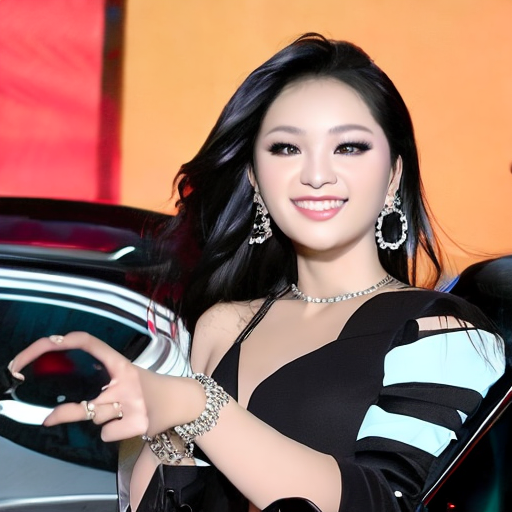

In [259]:
img = pipeline('a photo of v1', num_inference_steps=20, guidance_scale=7.5).images[0]

display(img)

In [260]:
pipeline.fuse_lora()


100%|█████████████████████████████████████████████████████████████████████████| 20/20 [02:11<00:00,  6.57s/it]


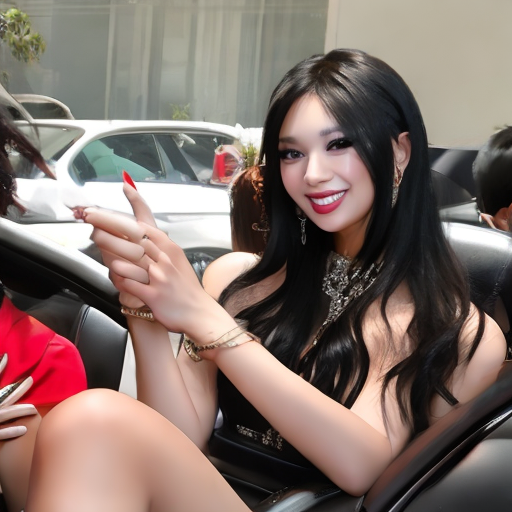

In [261]:
img = pipeline('a photo of v1', num_inference_steps=20, guidance_scale=7.5).images[0]

display(img)

In [262]:
pipeline.unet

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): LoRACompatibleLinear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): LoRACompatibleLinear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): LoRACompatibleConv(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): LoRACompatibleLinear(in_features=320, out_features=320, bias=False)
                (to_k): LoRACompatibleLinear(in_features=320, out_features=320

In [263]:
pipeline.unfuse_lora()

In [264]:
pipeline.unet

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): LoRACompatibleLinear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): LoRACompatibleLinear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): LoRACompatibleConv(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): LoRACompatibleLinear(in_features=320, out_features=320, bias=False)
                (to_k): LoRACompatibleLinear(in_features=320, out_features=320